In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA L4


In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import itertools
import json
import joblib

from src.dataset_loaders import get_ptb_xl_fmm_dataset, get_shaoxing_fmm_dataset
from src.preprocess_data import preprocess_data_fmm

from src.models.VAE import VAE1D, compute_scores
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve, confusion_matrix

In [3]:
%load_ext autoreload
%autoreload 2

### `Load the Data`

In [4]:
from src.utils import find_data_subfolder, find_folder

DATA_DIR = find_data_subfolder('')

In [5]:
print("Loading FMM-enhanced PTB-XL dataset...")
data_dict_ptb_xl = get_ptb_xl_fmm_dataset(
    datapath=DATA_DIR,
    num_leads=1,
    lead=0,
    num_waves=5,
    sequence_length=2048,
    delete_high_A=False
)
print("Dataset loaded successfully.")

Loading FMM-enhanced PTB-XL dataset...


Loading 'train':   0%|          | 0/95868 [00:00<?, ?it/s]

Loading 'train':   1%|          | 545/95868 [00:00<00:17, 5442.06it/s]

Loading 'train':   1%|          | 1100/95868 [00:00<00:17, 5500.23it/s]

Loading 'train':   2%|▏         | 1651/95868 [00:00<00:17, 5475.72it/s]

...

Loading 'test':  88%|████████▊ | 9558/10907 [00:01<00:00, 5612.09it/s]

Loading 'test':  93%|█████████▎| 10121/10907 [00:01<00:00, 5614.78it/s]

Loading 'test':  98%|█████████▊| 10683/10907 [00:01<00:00, 5614.38it/s]

Loading 'test': 100%|██████████| 10907/10907 [00:01<00:00, 5607.45it/s]

Dataset loaded successfully.


In [6]:
print("Loading FMM-enhanced Shaoxing dataset...")
data_dict_shaoxing = get_shaoxing_fmm_dataset(
    datapath=DATA_DIR,
    num_leads=1,
    lead=0,  
    num_waves=5,
    sequence_length=2048,
    delete_high_A=False
)
print("Dataset loaded successfully.")

Loading FMM-enhanced Shaoxing dataset...


Loading 'all':   0%|          | 0/69845 [00:00<?, ?it/s]

Loading 'all':   1%|          | 530/69845 [00:00<00:13, 5295.17it/s]

Loading 'all':   2%|▏         | 1060/69845 [00:00<00:13, 5254.40it/s]

Loading 'all':   2%|▏         | 1588/69845 [00:00<00:12, 5260.24it/s]

...

Loading 'all':  98%|█████████▊| 68353/69845 [00:12<00:00, 5217.06it/s]

Loading 'all':  99%|█████████▊| 68878/69845 [00:13<00:00, 5225.62it/s]

Loading 'all':  99%|█████████▉| 69401/69845 [00:13<00:00, 5184.60it/s]

Loading 'all': 100%|██████████| 69845/69845 [00:13<00:00, 5272.58it/s]

Dataset loaded successfully.


In [7]:
print("PTB-XL keys:", data_dict_ptb_xl.keys())
print("Shaoxing keys:", data_dict_shaoxing.keys())

PTB-XL keys: dict_keys(['train', 'test', 'params'])
Shaoxing keys: dict_keys(['train', 'test', 'params'])


In [8]:
print(data_dict_ptb_xl['train'].keys())
print(data_dict_shaoxing['train'].keys())

dict_keys(['data', 'coefficients', 'peak_index', 'records', 'labels', 'sizes', 'sorted', 'ang'])
dict_keys(['data', 'labels', 'coefficients', 'coefficients_ang', 'sizes', 'records'])


#### Join the datasets

In [9]:
ptb = data_dict_ptb_xl
shx = data_dict_shaoxing

# Record ids are numbered per source folder, so give each source its own id space.
# PTB train/test are separate official (patient-stratified) folders, hence different
# offsets; Chapman train/test are split out of a single pool and share a space.
REC_OFFSET = {('train', 'ptb'): 0, ('test', 'ptb'): 2_000_000,
              ('train', 'shx'): 1_000_000, ('test', 'shx'): 1_000_000}

def _join(split):
    ang_shx = 'coefficients_ang'
    return {
        'data':             np.concatenate([ptb[split]['data'],         shx[split]['data']], axis=0),
        'labels':           np.concatenate([ptb[split]['labels'],       shx[split]['labels']], axis=0),
        'sizes':            np.concatenate([ptb[split]['sizes'],        shx[split]['sizes']], axis=0),
        'coefficients':     np.concatenate([ptb[split]['coefficients'], shx[split]['coefficients']], axis=0),
        'coefficients_ang': np.concatenate([ptb[split]['ang'],          shx[split][ang_shx]], axis=0),
        'records':          np.concatenate([ptb[split]['records'] + REC_OFFSET[(split, 'ptb')],
                                            shx[split]['records'] + REC_OFFSET[(split, 'shx')]], axis=0),
    }

data_dict_train = _join('train')
data_dict_test  = _join('test')

# both use the same normal_class
data_dict_params = ptb["params"]  # or shx["params"], they match

data_dict = {
    "train":  data_dict_train,
    "test":   data_dict_test,
    "params": data_dict_params
}

overlap = set(data_dict_train['records'].tolist()) & set(data_dict_test['records'].tolist())
assert not overlap, f"{len(overlap)} recordings leak between dev and test"
print('no recording is shared between dev and test')


no recording is shared between dev and test


### `Preprocess the data`
We trim each array so that its number of samples is a multiple of batch_size

No normalization or data augmentation is applied yet, so the logic is the same for train and test

In [10]:
raw_dev = {
    "data":            data_dict["train"]["data"],
    "labels":          data_dict["train"]["labels"],
    "sizes":           data_dict["train"]["sizes"],
    "coefficients":    data_dict["train"]["coefficients"],
    "coefficients_ang":data_dict["train"]["coefficients_ang"],
    "records":         data_dict["train"]["records"],
}
dev_proc = preprocess_data_fmm(
    raw_dev,
    dataset_params=data_dict["params"],
    fs=100,
    batch_size=32,
    split_ecg=False
)

raw_test = {
    "data":            data_dict["test"]["data"],
    "labels":          data_dict["test"]["labels"],
    "sizes":           data_dict["test"]["sizes"],
    "coefficients":    data_dict["test"]["coefficients"],
    "coefficients_ang":data_dict["test"]["coefficients_ang"],
    "records":         data_dict["test"]["records"],
}

test_proc = preprocess_data_fmm(
    raw_test,
    dataset_params=data_dict["params"],
    fs=100,
    batch_size=32,
    split_ecg=False
)


Number of samples per class: [11616, 3019, 14707, 54056, 13127]
Number of samples per class: [1420, 378, 1655, 6042, 1533]


In [11]:
data_dict = {
    "train": dev_proc,
    "test":  test_proc,
    "params": data_dict["params"]
}

#### Extract signals and coefficients

In [12]:
X_dev_signal_raw = data_dict['train']['data'].astype(np.float32)
X_dev_coeffs_raw = data_dict['train']['coefficients'].astype(np.float32)
y_dev = data_dict['train']['labels'].astype(int)
records_dev = data_dict['train']['records']

X_test_signal_raw = data_dict['test']['data'].astype(np.float32)
X_test_coeffs_raw = data_dict['test']['coefficients'].astype(np.float32)
y_test = data_dict['test']['labels'].astype(int)
records_test = data_dict['test']['records']

print("Data loading complete.")
print(f"Train signal shape: {X_dev_signal_raw.shape}, Train coeffs shape: {X_dev_coeffs_raw.shape}")
print(f"Recordings: dev {len(np.unique(records_dev))}, test {len(np.unique(records_test))}")


Data loading complete.
Train signal shape: (151808, 2048, 1), Train coeffs shape: (151808, 21)
Recordings: dev 20907, test 3254


In [13]:
normal_class_id = data_dict['params']['normal_class']

dev_norm_signal_raw = X_dev_signal_raw[y_dev == normal_class_id]
dev_norm_coeffs_raw = X_dev_coeffs_raw[y_dev == normal_class_id]
dev_norm_records = records_dev[y_dev == normal_class_id]
dev_ano_signal_raw = X_dev_signal_raw[y_dev != normal_class_id]
dev_ano_coeffs_raw = X_dev_coeffs_raw[y_dev != normal_class_id]
dev_ano_records = records_dev[y_dev != normal_class_id]


#### Torch Tensors

In [14]:
dev_norm_signal_tensor_raw = torch.tensor(dev_norm_signal_raw).permute(0, 2, 1)
dev_ano_signal_tensor_raw = torch.tensor(dev_ano_signal_raw).permute(0, 2, 1)

dev_norm_coeffs_tensor_raw = torch.tensor(dev_norm_coeffs_raw)
dev_ano_coeffs_tensor_raw = torch.tensor(dev_ano_coeffs_raw)

### Normalize the data

In [15]:
mean_x = dev_norm_signal_raw.mean()
std_x  = dev_norm_signal_raw.std()
mean_c = dev_norm_coeffs_raw.mean(axis=0)
std_c  = dev_norm_coeffs_raw.std(axis=0)

In [16]:
X_dev_signal = (X_dev_signal_raw - mean_x) / (std_x  + 1e-8)
X_test_signal  = (X_test_signal_raw  - mean_x) / (std_x  + 1e-8)

X_dev_coeffs = (X_dev_coeffs_raw - mean_c) / (std_c  + 1e-8)
X_test_coeffs  = (X_test_coeffs_raw  - mean_c) / (std_c  + 1e-8)

#### Normilized splits

In [17]:
dev_norm_signal = X_dev_signal[y_dev == normal_class_id]
dev_norm_coeffs = X_dev_coeffs[y_dev == normal_class_id]
dev_ano_signal  = X_dev_signal[y_dev != normal_class_id]
dev_ano_coeffs  = X_dev_coeffs[y_dev != normal_class_id]

test_norm_signal = X_test_signal[y_test == normal_class_id]
test_norm_coeffs = X_test_coeffs[y_test == normal_class_id] 
test_ano_signal  = X_test_signal[y_test != normal_class_id]
test_ano_coeffs  = X_test_coeffs[y_test != normal_class_id]

#### Tensors

In [18]:
# Conv1d expects (Batch, Channels, Length)

dev_norm_signal_tensor = torch.tensor(dev_norm_signal).permute(0, 2, 1)
dev_ano_signal_tensor = torch.tensor(dev_ano_signal).permute(0, 2, 1)
test_norm_signal_tensor = torch.tensor(test_norm_signal).permute(0, 2, 1)
test_ano_signal_tensor = torch.tensor(test_ano_signal).permute(0, 2, 1)

dev_norm_coeffs_tensor = torch.tensor(dev_norm_coeffs)
dev_ano_coeffs_tensor = torch.tensor(dev_ano_coeffs)
test_norm_coeffs_tensor = torch.tensor(test_norm_coeffs)
test_ano_coeffs_tensor = torch.tensor(test_ano_coeffs)

print(f"VAE training set size (normals only): {len(dev_norm_signal_tensor)}")
print(f"Final test set size (normals): {len(test_norm_signal_tensor)}")

VAE training set size (normals only): 54056
Final test set size (normals): 6042


## Save the data

In [19]:
data_out_dir = find_folder('.', 'data')
out_dir_data_proc = data_out_dir + "/data_processed"

os.makedirs(out_dir_data_proc, exist_ok=True)

np.savez_compressed(
    os.path.join(out_dir_data_proc, "data_processed.npz"),
    # Raw
    X_dev_signal_raw   = X_dev_signal_raw,
    X_dev_coeffs_raw   = X_dev_coeffs_raw,
    y_dev              = y_dev,
    X_test_signal_raw  = X_test_signal_raw,
    X_test_coeffs_raw  = X_test_coeffs_raw,
    y_test             = y_test,

    # Recording ids, so downstream splits can be grouped by recording
    records_dev        = records_dev,
    records_test       = records_test,

    # Normalized
    X_dev_signal_normalized  = X_dev_signal,
    X_dev_coeffs_normalized  = X_dev_coeffs,
    X_test_signal_normalized = X_test_signal,
    X_test_coeffs_normalized = X_test_coeffs,

    # Normalization parameters
    mean_x             = mean_x,
    std_x              = std_x,
    mean_c             = mean_c,
    std_c              = std_c,

    normal_class_id    = normal_class_id,
)


In [20]:
batch_size = 64

# `HP sweep`

In [21]:
# Helper function to split the healthy dev set before normalization. 
# We sample anomalies for the validation set so we can measure how well it separates.
# Finally we normalize train and validation using the train statistics.

from src.data_spitting import split_train_val_with_raw_dev

In [22]:
# The split is grouped by recording: every recording contributes several beats,
# so splitting beats at random would leave the same patient in train and val.
train_ds, val_ds, stats, sig_tr, coe_tr, sig_vn, coe_vn, sig_va, coe_va, idx_val_ano = split_train_val_with_raw_dev(
    dev_norm_signal_raw, dev_norm_coeffs_raw, dev_norm_records,
    dev_ano_signal_raw,  dev_ano_coeffs_raw,  dev_ano_records,
    val_frac=0.2, seed=42
) # Val has normals and anomalies, train does not
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

labels_val = val_ds.tensors[2].numpy()


For XGBoost

In [23]:
# Anomaly indices for Train, making sure not to reuse the validation ones to avoid leakage
all_ano = np.arange(len(dev_ano_signal_raw))
idx_tr_ano = np.setdiff1d(all_ano, idx_val_ano) # complemento de idx_val_ano

# Normalize anomalies
sig_tr_ano = (dev_ano_signal_raw[idx_tr_ano] - stats['mean_sig']) / stats['std_sig']
coe_tr_ano = (dev_ano_coeffs_raw[idx_tr_ano] - stats['mean_coe']) / stats['std_coe']

train_ano_signal_tensor = torch.tensor(sig_tr_ano).permute(0,2,1)
train_ano_coeffs_tensor = torch.tensor(coe_tr_ano)

train_norm_signal_tensor = train_ds.tensors[0]
train_norm_coeffs_tensor = train_ds.tensors[1]

Sweep

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
grid = {
    'beta': [1.0, 4.0, 10.0],
    'lr': [1e-3, 5e-4, 1e-4],
    'latent_dim': [16, 32, 64],
    'n_blocks': [2, 3]
}

combos = list(itertools.product( 
    grid['beta'], grid['lr'], grid['latent_dim'], grid['n_blocks']
))

hp_epochs = 15

In [26]:
results = []

for beta, lr, latent_dim, n_blocks in tqdm(combos, desc="Hyperparam sweep", total=len(combos)):
    model = VAE1D(input_ch=1, coeff_ch=dev_norm_coeffs.shape[1], latent_dim=latent_dim, n_blocks=n_blocks).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Train on train_loader (normals only)
    for _ in tqdm(range(hp_epochs), desc="VAE epochs", leave=False):
        model.train()
        for x_signal, x_coeffs, _ in train_loader:
            x_s, x_c = x_signal.to(device), x_coeffs.to(device)
            recon, mu, logv = model(x_s, x_c)
            recon_loss = nn.functional.mse_loss(recon, x_s)
            kl_loss = (-0.5 * (1 + logv - mu.pow(2) - logv.exp()).sum()) / x_s.size(0)
            loss = recon_loss + beta * kl_loss
            optimizer.zero_grad(); loss.backward(); optimizer.step()

    # ELBO on validation
    errs_val, zs_val = compute_scores(model, val_loader, device, beta)
    errs_val = np.nan_to_num(errs_val, nan=0.0, posinf=1e6, neginf=-1e6) # para NaNs/Infs
    scores_val = -errs_val
    labels_val = val_ds.tensors[2].numpy()
    vae_auc = roc_auc_score(labels_val, scores_val)
    
    # XGB train set = Train normals + anomalies
    X_tr_sigs  = torch.cat([train_norm_signal_tensor, train_ano_signal_tensor], dim=0)
    X_tr_coefs = torch.cat([train_norm_coeffs_tensor, train_ano_coeffs_tensor], dim=0)
    y_tr       = np.concatenate([
                     np.zeros(len(train_norm_signal_tensor)),
                     np.ones (len(train_ano_signal_tensor))
                 ])

    tr_clf_loader = DataLoader(
        TensorDataset(X_tr_sigs, X_tr_coefs, torch.zeros(len(X_tr_sigs))),
        batch_size=batch_size,
        shuffle=False
    )

    # Scores and latent representations on the train set for XGB
    errs_tr, zs_tr = compute_scores(model, tr_clf_loader, device, beta)
    errs_tr = np.nan_to_num(errs_tr, nan=0.0, posinf=1e6, neginf=-1e6) 
    X_tr = np.hstack([(-errs_tr).reshape(-1,1), zs_tr])
    
    # Train XGBoost on the train set just built
    clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    clf.fit(X_tr, y_tr)

    # XGBoost en val set
    errs_val2, zs_val2 = compute_scores(model, val_loader, device, beta)
    errs_val2 = np.nan_to_num(errs_val2, nan=0.0, posinf=1e6, neginf=-1e6)
    X_val = np.hstack([(-errs_val2).reshape(-1,1), zs_val2])
    probs = clf.predict_proba(X_val)[:,1]
    xgb_auc = roc_auc_score(labels_val, probs)

    results.append({
        'beta': beta,
        'lr': lr,
        'latent_dim': latent_dim,
        'n_blocks': n_blocks,
        'vae_auc': vae_auc,
        'xgb_auc': xgb_auc
    })
    tqdm.write(f"β={beta}, lr={lr}, ld={latent_dim}, nb={n_blocks} → VAE AUC={vae_auc:.3f}, XGB AUC={xgb_auc:.3f}")
    

best_hps = max(results, key=lambda x: x['xgb_auc'])
print("Best hyperparameters (by XGB AUC):", best_hps)


Hyperparam sweep:   0%|          | 0/54 [00:00<?, ?it/s]

VAE epochs:   0%|          | 0/15 [00:00<?, ?it/s]

/home/anatissera/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [23:38:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


β=1.0, lr=0.001, ld=16, nb=2 → VAE AUC=0.826, XGB AUC=0.902


VAE epochs:   0%|          | 0/15 [00:00<?, ?it/s]

...

/home/anatissera/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:35:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


β=10.0, lr=0.0001, ld=64, nb=2 → VAE AUC=0.827, XGB AUC=0.896


VAE epochs:   0%|          | 0/15 [00:00<?, ?it/s]

/home/anatissera/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:36:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


β=10.0, lr=0.0001, ld=64, nb=3 → VAE AUC=0.827, XGB AUC=0.895
Best hyperparameters (by XGB AUC): {'beta': 1.0, 'lr': 0.001, 'latent_dim': 64, 'n_blocks': 2, 'vae_auc': 0.8270442565549863, 'xgb_auc': 0.9227317241058381}


In [27]:
# Keep the winning configuration found by the sweep above.
# (It used to be overwritten here by a hard-coded dict, which discarded the sweep.)
print("Best hyperparameters (by XGB AUC):", best_hps)


Best hyperparameters (by XGB AUC): {'beta': 1.0, 'lr': 0.001, 'latent_dim': 64, 'n_blocks': 2, 'vae_auc': 0.8270442565549863, 'xgb_auc': 0.9227317241058381}


In [28]:
df = pd.DataFrame(results)
print(df)

    beta      lr  latent_dim  n_blocks   vae_auc   xgb_auc
0    1.0  0.0010          16         2  0.826401  0.902475
1    1.0  0.0010          16         3  0.826332  0.867635
2    1.0  0.0010          32         2  0.828881  0.894743
3    1.0  0.0010          32         3  0.826856  0.914491
4    1.0  0.0010          64         2  0.827044  0.922732
5    1.0  0.0010          64         3  0.826794  0.920656
6    1.0  0.0005          16         2  0.826396  0.892601
7    1.0  0.0005          16         3  0.826723  0.901238
8    1.0  0.0005          32         2  0.826687  0.902947
9    1.0  0.0005          32         3  0.826946  0.902956
10   1.0  0.0005          64         2  0.827181  0.904370
11   1.0  0.0005          64         3  0.826375  0.922261
12   1.0  0.0001          16         2  0.826606  0.895418
13   1.0  0.0001          16         3  0.826560  0.897147
14   1.0  0.0001          32         2  0.826578  0.908316
15   1.0  0.0001          32         3  0.826593  0.9084

In [29]:
hps = {**best_hps, 'batch_size': batch_size, 'epochs': 35}

out_dir_models_n_params = find_folder('.', 'saved_models_and_params')
os.makedirs(out_dir_models_n_params, exist_ok=True)

hps_path = os.path.join(out_dir_models_n_params, "best_hps.json")
clean_hps = {k: float(v) if isinstance(v, (np.floating, np.integer)) else v for k, v in hps.items()}

with open(hps_path, "w") as f:
    json.dump(clean_hps, f, indent=2)

print(f"Hyper-parameters saved to {out_dir_models_n_params}/best_hps.json")


Hyper-parameters saved to /home/anatissera/ecg/saved_models_and_params/best_hps.json


In [30]:
from IPython.display import display

def smart_format(x):
    if isinstance(x, float):
        return f"{x:.5g}"
    return x

df = pd.DataFrame([best_hps])
styled_df = df.style.format(smart_format).set_caption("Best hyperparameters (by XGB AUC)")

display(styled_df)

,beta,lr,latent_dim,n_blocks,vae_auc,xgb_auc
0,1,0.001,64,2,0.82704,0.92273


In [31]:
batch_size = 64

# Retraining with Best hyperparameters but more epochs

In [32]:
latent_dim = best_hps['latent_dim']
lr = best_hps['lr']
n_blocks = best_hps['n_blocks']
beta_value = best_hps['beta']
epochs = 40

NUM_INPUT_CH = dev_norm_signal_tensor.shape[1]  # 1
NUM_COEFF_CH = dev_norm_coeffs_tensor.shape[1]  # 21

In [33]:
print(f"Using device: {device}, Signal Channels: {NUM_INPUT_CH}, Coeff Channels: {NUM_COEFF_CH}")

model = VAE1D(input_ch=NUM_INPUT_CH, coeff_ch=NUM_COEFF_CH, latent_dim=latent_dim, n_blocks=n_blocks).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

Using device: cuda, Signal Channels: 1, Coeff Channels: 21


In [34]:
train_recon_losses = []
train_kl_losses    = []
train_total_losses = []

print("Starting VAE training...")
for epoch in tqdm(range(epochs), desc="Training epochs"):
    model.train()
    total_loss = 0.0
    epoch_recon = 0.0
    epoch_kl    = 0.0
    for x_signal, x_coeffs, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        x_signal, x_coeffs = x_signal.to(device), x_coeffs.to(device)
        
        recon, mu, logv = model(x_signal, x_coeffs)
        
        recon_loss = nn.functional.mse_loss(recon, x_signal)
        kl_loss = (-0.5 * (1 + logv - mu.pow(2) - logv.exp()).sum()) / x_signal.size(0)
        loss = recon_loss + beta_value * kl_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
        epoch_recon += recon_loss.item() * x_signal.size(0)
        epoch_kl    += kl_loss.item()    * x_signal.size(0)

    N = len(train_loader.dataset) 
    train_recon_losses.append(epoch_recon / N)
    train_kl_losses.append(epoch_kl / N)
    train_total_losses.append(train_recon_losses[-1] + beta_value * train_kl_losses[-1])

    print(f"Epoch {epoch+1}/{epochs}  Recon={train_recon_losses[-1]:.4f}  KL={train_kl_losses[-1]:.4f}  Total={train_total_losses[-1]:.4f},  VAE Loss: {total_loss/len(train_loader):.4f}")


Starting VAE training...


Training epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/40:   0%|          | 0/679 [00:00<?, ?it/s]

Epoch 1/40  Recon=1.2180  KL=3.6794  Total=4.8974,  VAE Loss: 4.8930


Epoch 2/40:   0%|          | 0/679 [00:00<?, ?it/s]

...

Epoch 38/40  Recon=0.9556  KL=0.0038  Total=0.9594,  VAE Loss: 0.9590


Epoch 39/40:   0%|          | 0/679 [00:00<?, ?it/s]

Epoch 39/40  Recon=0.9557  KL=0.0065  Total=0.9622,  VAE Loss: 0.9621


Epoch 40/40:   0%|          | 0/679 [00:00<?, ?it/s]

Epoch 40/40  Recon=0.9555  KL=0.0028  Total=0.9583,  VAE Loss: 0.9582


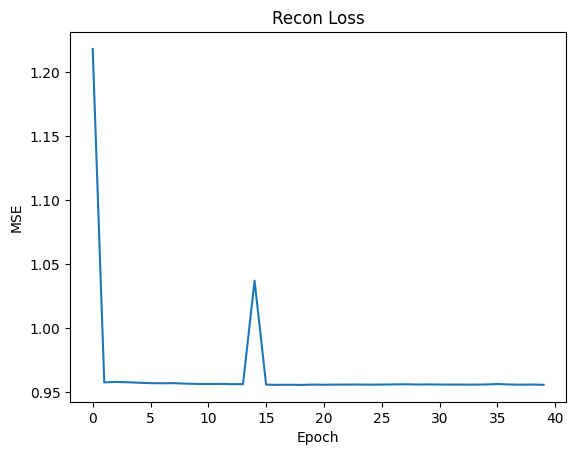

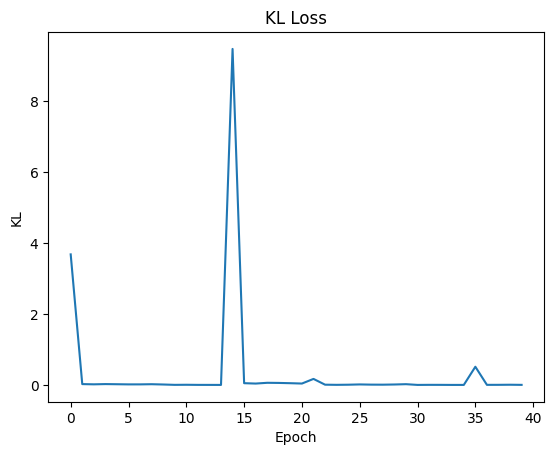

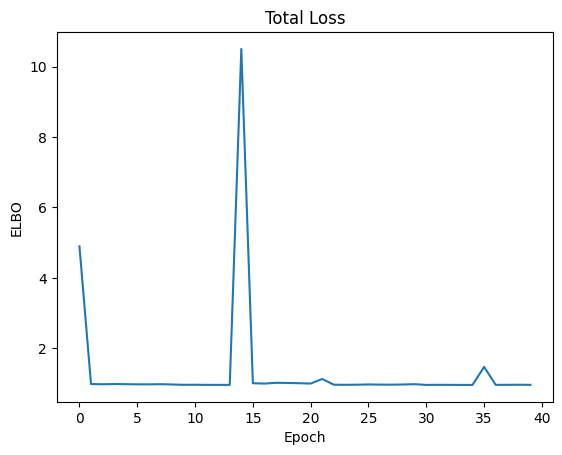

In [35]:

import matplotlib.pyplot as plt

plt.figure(); plt.plot(train_recon_losses); plt.title('Recon Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.show()
plt.figure(); plt.plot(train_kl_losses);    plt.title('KL Loss');    plt.xlabel('Epoch'); plt.ylabel('KL');  plt.show()
plt.figure(); plt.plot(train_total_losses); plt.title('Total Loss'); plt.xlabel('Epoch'); plt.ylabel('ELBO');plt.show()


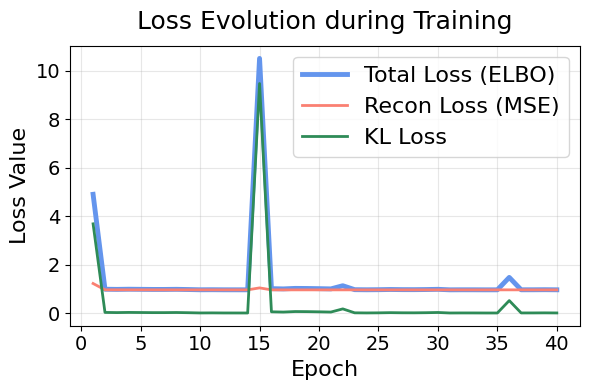

In [36]:
import matplotlib.pyplot as plt

from src.plot_metrics import plot_training_losses

plot_training_losses(train_recon_losses, train_kl_losses, train_total_losses, lw=2, font_size=16)

### Testing in train set before XGBoost

We compute KL, MSE, ELBO and scores

In [37]:
from torch.utils.data import DataLoader, TensorDataset

tr_loader_all = DataLoader(
    TensorDataset(
        torch.cat([train_norm_signal_tensor, train_ano_signal_tensor]),
        torch.cat([train_norm_coeffs_tensor, train_ano_coeffs_tensor]),
        torch.cat([torch.zeros(len(train_norm_signal_tensor)), torch.ones(len(train_ano_signal_tensor))])
    ),
    batch_size=batch_size
)

model.eval()
mse_list = []
kl_list  = []
labels_vae_tr   = []

with torch.no_grad():
    for x_s, x_c, y in tr_loader_all:
        x_s, x_c = x_s.to(device), x_c.to(device)
        recon, mu, logv = model(x_s, x_c)
        mse_batch = ((recon - x_s)**2).mean(dim=[1,2]).cpu().numpy()
        kl_batch  = (-0.5*(1 + logv - mu.pow(2) - logv.exp()).sum(dim=1)).cpu().numpy()

        mse_list.append(mse_batch)
        kl_list.append(kl_batch)
        labels_vae_tr.append(y.numpy())

mse_all_vae_tr = np.concatenate(mse_list)
kl_all_vae_tr  = np.concatenate(kl_list)
labels_vae_tr  = np.concatenate(labels_vae_tr)

In [38]:
print("MSE promedio:  normales =",
      mse_all_vae_tr[labels_vae_tr==0].mean(), 
      ", anomalous =", mse_all_vae_tr[labels_vae_tr==1].mean())
print("KL promedio:   normales =",
      kl_all_vae_tr[labels_vae_tr==0].mean(), 
      ", anomalous =", kl_all_vae_tr[labels_vae_tr==1].mean())

# -ELBO = mse + beta*kl as the anomaly score
scores_vae_tr = mse_all_vae_tr + beta_value * kl_all_vae_tr
roc_auc_vae_tr = roc_auc_score(labels_vae_tr, scores_vae_tr)
print("Anomaly detection ROC-AUC (VAE):", roc_auc_vae_tr)

MSE promedio:  normales = 0.95538294 , anomalous = 10.188494
KL promedio:   normales = 0.0031067939 , anomalous = 0.034328684
Anomaly detection ROC-AUC (VAE): 0.8143658777279598


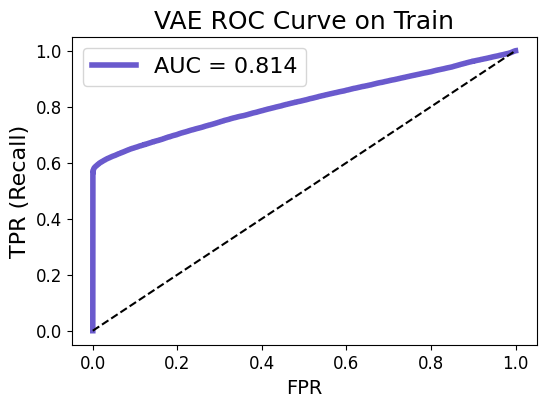

In [39]:
fpr, tpr, thr = roc_curve(labels_vae_tr, scores_vae_tr) 

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_vae_tr:.3f}", color = "slateblue", linewidth=4)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel("TPR (Recall)", fontsize=16)
plt.title("VAE ROC Curve on Train", fontsize=18)
plt.legend(fontsize = 16)
plt.show()

In [40]:
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold_vae = thr[best_idx]

print("Best Youden J threshold:", best_threshold_vae)

y_pred_vae_tr = (scores_vae_tr >= best_threshold_vae).astype(int)

from src.utils import display_metrics_as_md
    
metrics_vae = {
    'roc_auc': roc_auc_vae_tr,
    'precision': precision_score(labels_vae_tr, y_pred_vae_tr),
    'recall': recall_score(labels_vae_tr, y_pred_vae_tr),
    'f1': f1_score(labels_vae_tr, y_pred_vae_tr),
    'accuracy': accuracy_score(labels_vae_tr, y_pred_vae_tr) 
    }

display_metrics_as_md(metrics_vae, title="VAE Metrics on Train Set")

Best Youden J threshold: 2.8744917


<h2 style='margin-bottom:0.3em'>VAE Metrics on Train Set</h2>
<p style='font-size:16px; margin:0.2em 0'><strong>Roc Auc:</strong> 0.8144</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Precision:</strong> 0.9845</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Recall:</strong> 0.5999</p>
<p style='font-size:16px; margin:0.2em 0'><strong>F1:</strong> 0.7455</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Accuracy:</strong> 0.7366</p>


### Testing in validation set before XGBoost

In [41]:
val_norm_signal_tensor = torch.tensor(sig_vn).permute(0,2,1)   
val_norm_coeffs_tensor = torch.tensor(coe_vn)                 

val_ano_signal_tensor  = torch.tensor(sig_va).permute(0,2,1)    
val_ano_coeffs_tensor  = torch.tensor(coe_va)                 

# balancear val set
N_norm_val = len(val_norm_signal_tensor)
N_ano_val  = len(val_ano_signal_tensor)
N_val = min(N_norm_val, N_ano_val)

norm_signals_val = val_norm_signal_tensor[:N_val]
ano_signals_val  = val_ano_signal_tensor[:N_val]
norm_coeffs_val  = val_norm_coeffs_tensor[:N_val]
ano_coeffs_val   = val_ano_coeffs_tensor[:N_val]

X_val_final_signal = torch.cat([norm_signals_val, ano_signals_val], dim=0)
X_val_final_coeffs = torch.cat([norm_coeffs_val, ano_coeffs_val], dim=0)

y_val_final = torch.tensor(
    np.concatenate([np.zeros(N_val), np.ones(N_val)]),
    dtype=torch.long
)

val_loader_final = DataLoader(TensorDataset(X_val_final_signal, X_val_final_coeffs, y_val_final), batch_size=batch_size)

In [42]:
mse_list_val, kl_list_val, labels_val = [], [], []

with torch.no_grad():
    for x_s, x_c, y in val_loader_final:
        x_s, x_c = x_s.to(device), x_c.to(device)
        recon, mu, logv = model(x_s, x_c)
        mse_batch = ((recon - x_s)**2).mean(dim=[1,2]).cpu().numpy()
        kl_batch  = (-0.5*(1 + logv - mu.pow(2) - logv.exp()).sum(dim=1)).cpu().numpy()

        mse_list_val.append(mse_batch)
        kl_list_val.append(kl_batch)
        labels_val.append(y.numpy())

mse_all_vae_val = np.concatenate(mse_list_val)
kl_all_vae_val  = np.concatenate(kl_list_val)
labels_vae_val  = np.concatenate(labels_val)

scores_vae_val  = mse_all_vae_val + beta_value * kl_all_vae_val
y_pred_vae_val = (scores_vae_val >= best_threshold_vae).astype(int)

from src.utils import display_metrics_as_md
    
metrics_vae_val = {
    'roc_auc': roc_auc_score(labels_vae_val, scores_vae_val),
    'precision': precision_score(labels_vae_val, y_pred_vae_val),
    'recall': recall_score(labels_vae_val, y_pred_vae_val),
    'f1': f1_score(labels_vae_val, y_pred_vae_val),
    'accuracy': accuracy_score(labels_vae_val, y_pred_vae_val) 
    }

display_metrics_as_md(metrics_vae_val, title="VAE Metrics on Val Set")

<h2 style='margin-bottom:0.3em'>VAE Metrics on Val Set</h2>
<p style='font-size:16px; margin:0.2em 0'><strong>Roc Auc:</strong> 0.6823</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Precision:</strong> 0.9308</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Recall:</strong> 0.3030</p>
<p style='font-size:16px; margin:0.2em 0'><strong>F1:</strong> 0.4572</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Accuracy:</strong> 0.6402</p>


## `Fit XGBoost`

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_curve, roc_auc_score, precision_recall_curve, confusion_matrix

In [44]:
X_tr_clf_signal = torch.cat([train_norm_signal_tensor, train_ano_signal_tensor], dim=0)
X_tr_clf_coeffs = torch.cat([train_norm_coeffs_tensor, train_ano_coeffs_tensor],   dim=0)
y_tr_clf     = torch.cat([
    torch.zeros(len(train_norm_signal_tensor), dtype=torch.long),
    torch.ones (len(train_ano_signal_tensor),  dtype=torch.long)
], dim=0)

tr_loader_clf = DataLoader(TensorDataset(X_tr_clf_signal, X_tr_clf_coeffs, y_tr_clf), batch_size=batch_size)

print("Extracting features from dev set for classifier training...")
errs_tr, zs_tr = compute_scores(model, tr_loader_clf, device, beta=beta_value)
errs_tr = np.nan_to_num(errs_tr, nan=0.0, posinf=1e6, neginf=-1e6)
zs_dev = np.nan_to_num(zs_tr, nan=0.0, posinf=1e6, neginf=-1e6)
X_train_clf = np.hstack([errs_tr.reshape(-1, 1), zs_dev])
y_train_clf = y_tr_clf.numpy()

print("Training XGBoost classifier...")
clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
clf.fit(X_train_clf, y_train_clf)
print("Classifier training complete.")

Extracting features from dev set for classifier training...


Training XGBoost classifier...


/home/anatissera/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:39:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classifier training complete.


### Find Threshold in train (Youden’s J on ROC)

In [45]:
# The decision threshold is NOT chosen here on the training data: doing so is
# optimistic, because the classifier has already seen those beats. It is chosen
# on the validation split (cell below), as the highest cut that still reaches
# TARGET_RECALL on the anomalous class -- for a screening tool a missed anomaly
# costs more than a false alarm.
from src.thresholds import threshold_for_recall
TARGET_RECALL = 0.80
print(f'threshold criterion: highest cut with recall >= {TARGET_RECALL} on validation')


threshold criterion: highest cut with recall >= 0.8 on validation


# Testing in validation set

In [46]:
print("Extracting features from the validation set...")
errs_val, zs_val = compute_scores(model, val_loader_final, device, beta=beta_value)
errs_val = np.nan_to_num(errs_val, nan=0.0, posinf=1e6, neginf=-1e6)
zs_test = np.nan_to_num(zs_val, nan=0.0, posinf=1e6, neginf=-1e6)
X_val_clf = np.hstack([errs_val.reshape(-1, 1), zs_test])
y_val_clf = y_val_final.numpy()

Extracting features from the validation set...


### `Final Results in Validation set`

In [47]:
print("Evaluating classifier on the validation set...")
probs_val = clf.predict_proba(X_val_clf)[:, 1]

# threshold picked on validation under the recall constraint
best_thresh_vtr = threshold_for_recall(y_val_clf, probs_val, TARGET_RECALL)
y_pred_val = (probs_val >= best_thresh_vtr).astype(int)
print(f"threshold = {best_thresh_vtr:.3f} "
      f"(validation recall {recall_score(y_val_clf, y_pred_val):.3f})")


Evaluating classifier on the validation set...
threshold = 0.402 (validation recall 0.800)


In [48]:
metrics = {
    'roc_auc': roc_auc_score(y_val_clf, probs_val),
    'precision': precision_score(y_val_clf, y_pred_val),
    'recall': recall_score(y_val_clf, y_pred_val),
    'f1': f1_score(y_val_clf, y_pred_val),
    'accuracy': accuracy_score(y_val_clf, y_pred_val)
}

from src.utils import display_metrics_as_md
display_metrics_as_md(metrics, "Final Metrics on Validation Set")

<h2 style='margin-bottom:0.3em'>Final Metrics on Validation Set</h2>
<p style='font-size:16px; margin:0.2em 0'><strong>Roc Auc:</strong> 0.8503</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Precision:</strong> 0.7399</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Recall:</strong> 0.8001</p>
<p style='font-size:16px; margin:0.2em 0'><strong>F1:</strong> 0.7688</p>
<p style='font-size:16px; margin:0.2em 0'><strong>Accuracy:</strong> 0.7594</p>


#### Confusion Matrix


Confusion matrix:
             Pred Neg  Pred Pos
Actual Neg      7654      2995
Actual Pos      2129      8520


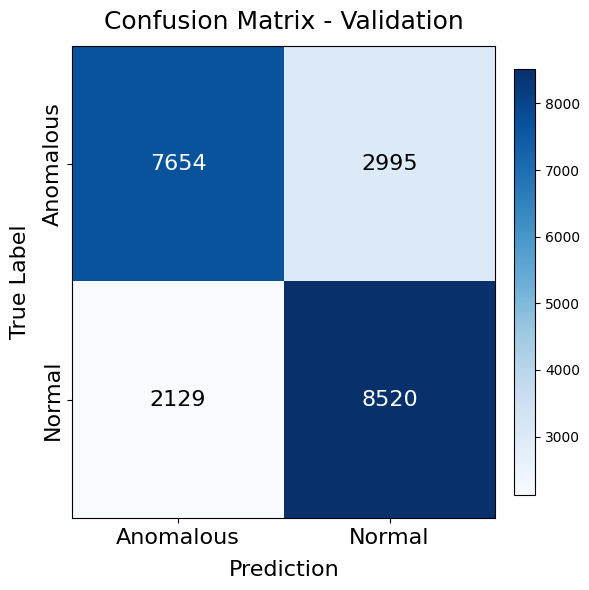

In [49]:
cm_val = confusion_matrix(y_val_clf, y_pred_val) 

cm_val_df = pd.DataFrame(
    cm_val,
    index=["Actual Neg","Actual Pos"],
    columns=["Pred Neg","Pred Pos"]
)
print("\nConfusion matrix:\n", cm_val_df)

from src.plot_metrics import plot_confusion_matrix

plot_confusion_matrix(cm_val, class_names=["Anomalous", "Normal"], title="Confusion Matrix - Validation")

#### ROC and PR Curves

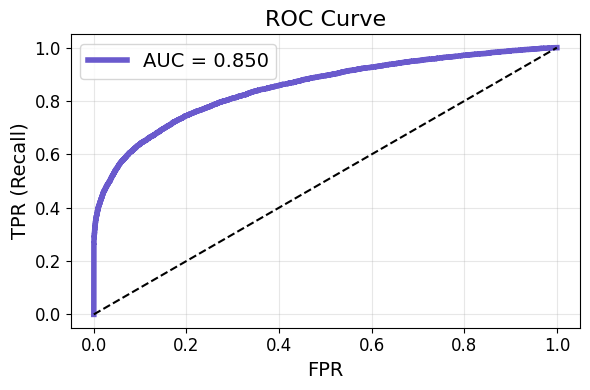

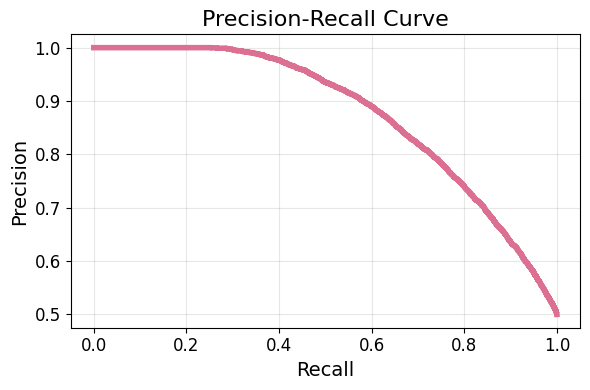

In [50]:
from sklearn.metrics import roc_curve

from src.plot_metrics import plot_roc_pr

plot_roc_pr(y_val_clf, probs_val, lw=4, font_size=14, roc_color='slateblue', pr_color='palevioletred')

# `Final training on the train split`

The final model is trained on the **train** split only, not on the whole development set.
Training on all of dev would leave no clean data to choose the decision threshold on: the
classifier would already have seen the validation beats, its scores on them would be
optimistic, and the threshold read off those scores does not transfer to new patients.


In [51]:
latent_dim = best_hps['latent_dim']
lr = best_hps['lr']
n_blocks = best_hps['n_blocks']
beta_value = best_hps['beta']
epochs = 35

In [52]:
print(f"Using device: {device}, Signal Channels: {NUM_INPUT_CH}, Coeff Channels: {NUM_COEFF_CH}")

# train split only (validation is held out for the threshold)
dev_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

model = VAE1D(input_ch=NUM_INPUT_CH, coeff_ch=NUM_COEFF_CH, latent_dim=latent_dim,
              n_blocks=n_blocks).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


Using device: cuda, Signal Channels: 1, Coeff Channels: 21


In [53]:
dev_recon_losses = []
dev_kl_losses    = []
dev_total_losses = []

print("Starting VAE training...")
for epoch in tqdm(range(epochs), desc="Training epochs"):
    model.train()
    total_loss = 0.0
    epoch_recon = 0.0
    epoch_kl    = 0.0
    for x_signal, x_coeffs, _ in tqdm(dev_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        x_signal, x_coeffs = x_signal.to(device), x_coeffs.to(device)
        
        recon, mu, logv = model(x_signal, x_coeffs)
        
        recon_loss = nn.functional.mse_loss(recon, x_signal)
        kl_loss = (-0.5 * (1 + logv - mu.pow(2) - logv.exp()).sum()) / x_signal.size(0)
        loss = recon_loss + beta_value * kl_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
        epoch_recon += recon_loss.item() * x_signal.size(0)
        epoch_kl    += kl_loss.item()    * x_signal.size(0)

    N = len(dev_loader.dataset) 
    dev_recon_losses.append(epoch_recon / N)
    dev_kl_losses.append(epoch_kl / N)
    dev_total_losses.append(dev_recon_losses[-1] + beta_value * dev_kl_losses[-1])

    print(f"Epoch {epoch+1}/{epochs}  Recon={dev_recon_losses[-1]:.4f}  KL={dev_kl_losses[-1]:.4f}  Total={dev_total_losses[-1]:.4f},  VAE Loss: {total_loss/len(dev_loader):.4f}")

# Save the model
torch.save(model.state_dict(), f"{out_dir_models_n_params}/vae_model.pth")
print(f"VAE model saved to {out_dir_models_n_params}vae_model.pth")

Starting VAE training...


Training epochs:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 1/35:   0%|          | 0/679 [00:00<?, ?it/s]

Epoch 1/35  Recon=1.1336  KL=2.2817  Total=3.4153,  VAE Loss: 3.4130


Epoch 2/35:   0%|          | 0/679 [00:00<?, ?it/s]

...

Epoch 33/35  Recon=0.9556  KL=0.0095  Total=0.9651,  VAE Loss: 0.9649


Epoch 34/35:   0%|          | 0/679 [00:00<?, ?it/s]

Epoch 34/35  Recon=0.9558  KL=0.0048  Total=0.9605,  VAE Loss: 0.9606


Epoch 35/35:   0%|          | 0/679 [00:00<?, ?it/s]

Epoch 35/35  Recon=0.9557  KL=0.0029  Total=0.9586,  VAE Loss: 0.9588
VAE model saved to /home/anatissera/ecg/saved_models_and_paramsvae_model.pth


In [54]:
os.makedirs(out_dir_models_n_params, exist_ok=True)

# parameters only
torch.save(model.state_dict(), os.path.join(out_dir_models_n_params, "vae_state.pth"))
print(f"VAE model parameters saved to {os.path.join(out_dir_models_n_params, 'vae_state.pth')}")

VAE model parameters saved to /home/anatissera/ecg/saved_models_and_params/vae_state.pth


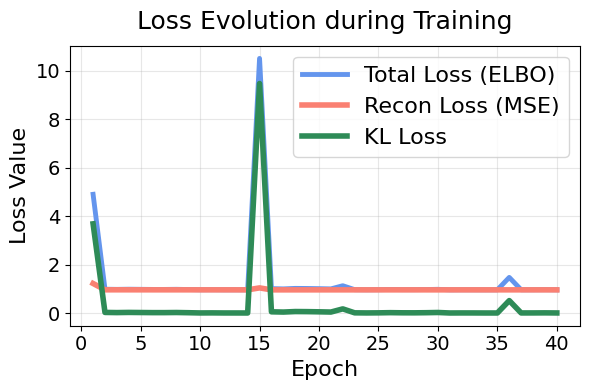

In [55]:
import matplotlib.pyplot as plt

from src.plot_metrics import plot_training_losses

plot_training_losses(train_recon_losses, train_kl_losses, train_total_losses, lw=4, font_size=16)

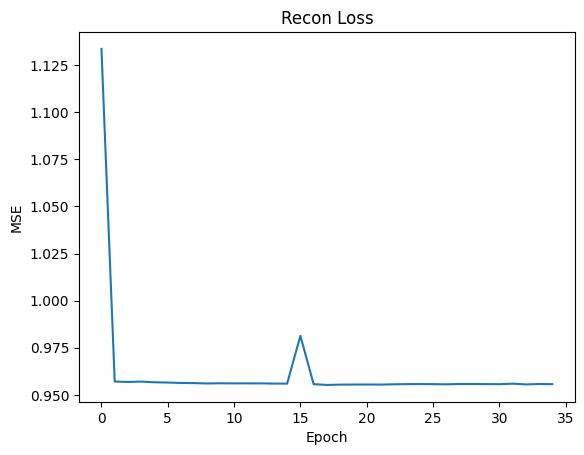

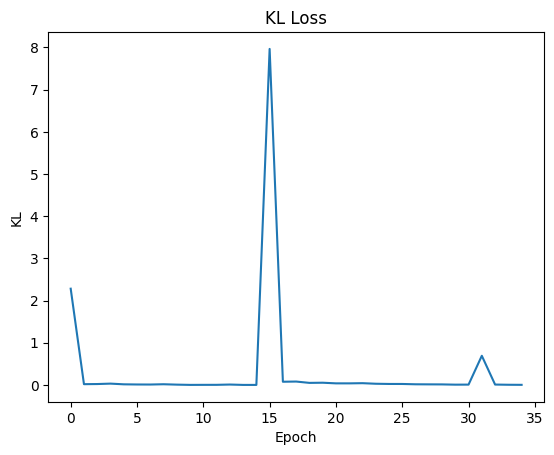

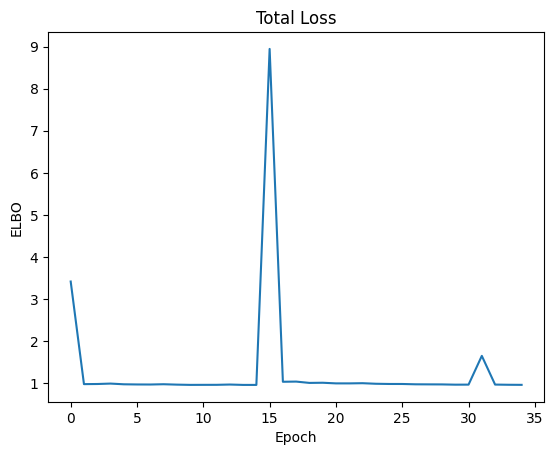

In [56]:

import matplotlib.pyplot as plt

plt.figure(); plt.plot(dev_recon_losses); plt.title('Recon Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.show()
plt.figure(); plt.plot(dev_kl_losses);    plt.title('KL Loss');    plt.xlabel('Epoch'); plt.ylabel('KL');  plt.show()
plt.figure(); plt.plot(dev_total_losses); plt.title('Total Loss'); plt.xlabel('Epoch'); plt.ylabel('ELBO');plt.show()


# XGBoost

In [57]:
# XGBoost is fitted on the TRAIN beats only: train normals plus the anomalies whose
# recordings are not in validation. Validation stays untouched for the threshold.
X_tr_clf_signal = torch.cat([train_norm_signal_tensor, train_ano_signal_tensor], dim=0)
X_tr_clf_coeffs = torch.cat([train_norm_coeffs_tensor, train_ano_coeffs_tensor], dim=0)
y_tr_clf = torch.tensor(np.concatenate([np.zeros(len(train_norm_signal_tensor)),
                                        np.ones(len(train_ano_signal_tensor))]), dtype=torch.long)

tr_loader_clf = DataLoader(TensorDataset(X_tr_clf_signal, X_tr_clf_coeffs, y_tr_clf),
                           batch_size=batch_size)

print("Extracting features from the train split for classifier training...")
errs_tr2, zs_tr2 = compute_scores(model, tr_loader_clf, device, beta=beta_value)
errs_tr2 = np.nan_to_num(errs_tr2, nan=0.0, posinf=1e6, neginf=-1e6)
zs_tr2 = np.nan_to_num(zs_tr2, nan=0.0, posinf=1e6, neginf=-1e6)
X_train_clf2 = np.hstack([errs_tr2.reshape(-1, 1), zs_tr2])

print("Training XGBoost classifier...")
clf = XGBClassifier(eval_metric='logloss')
clf.fit(X_train_clf2, y_tr_clf.numpy())

# recompute validation features with THIS model, so the threshold matches it
errs_v2, zs_v2 = compute_scores(model, val_loader_final, device, beta=beta_value)
errs_v2 = np.nan_to_num(errs_v2, nan=0.0, posinf=1e6, neginf=-1e6)
zs_v2 = np.nan_to_num(zs_v2, nan=0.0, posinf=1e6, neginf=-1e6)
X_val_clf = np.hstack([errs_v2.reshape(-1, 1), zs_v2])
y_val_clf = y_val_final.numpy()
print("Classifier training complete.")


Extracting features from the train split for classifier training...


Training XGBoost classifier...


Classifier training complete.


In [58]:
# Same rule for the final model: pick the threshold on validation, never on the
# data the classifier was fitted on.
probs_val_final = clf.predict_proba(X_val_clf)[:, 1]
best_thresh = threshold_for_recall(y_val_clf, probs_val_final, TARGET_RECALL)
print(f"threshold (recall >= {TARGET_RECALL} on validation): {best_thresh:.3f} "
      f"-> validation recall {recall_score(y_val_clf, (probs_val_final >= best_thresh).astype(int)):.3f}")


threshold (recall >= 0.8 on validation): 0.389 -> validation recall 0.800


## Save the final model

In [59]:
# modelo
model_path = os.path.join(out_dir_models_n_params, "xgb_clf.joblib")
joblib.dump(clf, model_path)
print(f"XGBoost model saved to {model_path}")

# threshold as JSON
th_path = os.path.join(out_dir_models_n_params, "threshold.json")
with open(th_path, "w") as f:
    json.dump({"best_thresh": float(best_thresh),
               "criterion": f"recall>={TARGET_RECALL} on validation"}, f)
print(f"Threshold saved to {th_path}")

XGBoost model saved to /home/anatissera/ecg/saved_models_and_params/xgb_clf.joblib
Threshold saved to /home/anatissera/ecg/saved_models_and_params/threshold.json
